# Đánh giá toàn diện bộ dữ liệu PROVEDIt 1-5 Person (Filtered)

Notebook này cung cấp các phân tích và thống kê chi tiết về bộ dữ liệu PROVEDIt, bao gồm:
1. Thống kê quy mô tập dữ liệu (số lượng file, số dòng).
2. Cấu trúc và Schema của dữ liệu.
3. Phân phối các giá trị đặc biệt (Nhiễm sắc thể X, Y ở AMEL và tín hiệu OL).
4. Đánh giá chất lượng tín hiệu (Peak Height/RFU).

*Lưu ý: Do kích thước dữ liệu rất lớn, notebook này sẽ tiến hành đọc mẫu một số file đại diện và tổng hợp thống kê theo từng thư mục thí nghiệm.*

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cấu hình thư mục gốc
base_dir = '/Users/nguyenthithutam/Desktop/TAWSEEM/PROVEDIt_1-5-Person CSVs Filtered'

plt.style.use('ggplot')
pd.set_option('display.max_columns', None)

## 1. Thống kê cấu trúc thư mục và số lượng file
Đếm số lượng file CSV theo từng bộ Kit, phân bố số lượng người (1-5 Person) và thời gian tiêm (Injection Time).

In [2]:
stats = {
    'kits': {},
    'persons': {},
    'injection_times': {},
    'total_files': 0
}

for kit_folder in sorted(os.listdir(base_dir)):
    kit_path = os.path.join(base_dir, kit_folder)
    if not os.path.isdir(kit_path): continue
    
    stats['kits'][kit_folder] = 0
    
    for root, dirs, files in os.walk(kit_path):
        for file in files:
            if file.endswith('.csv'):
                stats['total_files'] += 1
                stats['kits'][kit_folder] += 1
                
                rel_path = os.path.relpath(root, kit_path)
                parts = rel_path.split(os.sep)
                if len(parts) >= 2:
                    person_dir, sec_dir = parts[0], parts[1]
                    stats['persons'][person_dir] = stats['persons'].get(person_dir, 0) + 1
                    stats['injection_times'][sec_dir] = stats['injection_times'].get(sec_dir, 0) + 1

print(f"Tổng số tệp CSV: {stats['total_files']}\n")
print("Phân phối theo Kit:")
for k, v in stats['kits'].items(): print(f"  - {k}: {v} tệp")

print("\nPhân phối theo số lượng người (NOC):")
for k, v in sorted(stats['persons'].items()): print(f"  - {k}: {v} tệp")

print("\nPhân phối theo thời gian tiêm (Injection Time):")
for k, v in sorted(stats['injection_times'].items()): print(f"  - {k}: {v} tệp")

Tổng số tệp CSV: 35

Phân phối theo Kit:
  - PROVEDIt_1-5-Person CSVs Filtered_3130_IDPlus28cycles: 6 tệp
  - PROVEDIt_1-5-Person CSVs Filtered_3130_PP16HS32cycles: 6 tệp
  - PROVEDIt_1-5-Person CSVs Filtered_3500_F6C29cycles_hlfrxn: 2 tệp
  - PROVEDIt_1-5-Person CSVs Filtered_3500_GF29cycles: 6 tệp
  - PROVEDIt_1-5-Person CSVs Filtered_3500_IDPlus29cycles: 15 tệp

Phân phối theo số lượng người (NOC):
  - 1-Person: 13 tệp
  - 2-5-Persons: 9 tệp
  - 2-Person: 3 tệp
  - 3-Person: 3 tệp
  - 4-Person: 3 tệp
  - 5-Person: 3 tệp

Phân phối theo thời gian tiêm (Injection Time):
  - 10 sec: 4 tệp
  - 15 sec: 8 tệp
  - 20 sec: 4 tệp
  - 25 sec: 7 tệp
  - 5 sec: 11 tệp


## 2. Kích thước tập dữ liệu và Schema
Lấy mẫu ngẫu nhiên vài file để xem các cột hiện có, các kiểu dữ liệu và tổng số dòng xấp xỉ.

In [3]:
sample_file = os.path.join(base_dir, 'PROVEDIt_1-5-Person CSVs Filtered_3130_IDPlus28cycles', '1-Person', '5 sec', 'RD14-0003_IP_5sec_GM_F_1P.csv')
df_sample = pd.read_csv(sample_file, low_memory=False)

print(f"Kích thước file mẫu: {df_sample.shape[0]} dòng, {df_sample.shape[1]} cột")
print("\nCác cột meta chính:")
print(df_sample.columns[:3].tolist())

print("\nCác cột dữ liệu (Allele, Size, Height):")
print(df_sample.columns[3:12].tolist(), "...")

display(df_sample.head())

Kích thước file mẫu: 44960 dòng, 303 cột

Các cột meta chính:
['Sample File', 'Marker', 'Dye']

Các cột dữ liệu (Allele, Size, Height):
['Allele 1', 'Size 1', 'Height 1', 'Allele 2', 'Size 2', 'Height 2', 'Allele 3', 'Size 3', 'Height 3'] ...


,Sample File,Marker,Dye,Allele 1,Size 1,Height 1,Allele 2,Size 2,Height 2,Allele 3,Size 3,Height 3,Allele 4,Size 4,Height 4,Allele 5,Size 5,Height 5,Allele 6,Size 6,Height 6,Allele 7,Size 7,Height 7,Allele 8,Size 8,Height 8,Allele 9,Size 9,Height 9,Allele 10,Size 10,Height 10,Allele 11,Size 11,Height 11,Allele 12,Size 12,Height 12,Allele 13,Size 13,Height 13,Allele 14,Size 14,Height 14,Allele 15,Size 15,Height 15,Allele 16,Size 16,Height 16,Allele 17,Size 17,Height 17,Allele 18,Size 18,Height 18,Allele 19,Size 19,Height 19,Allele 20,Size 20,Height 20,Allele 21,Size 21,Height 21,Allele 22,Size 22,Height 22,Allele 23,Size 23,Height 23,Allele 24,Size 24,Height 24,Allele 25,Size 25,Height 25,Allele 26,Size 26,Height 26,Allele 27,Size 27,Height 27,Allele 28,Size 28,Height 28,Allele 29,Size 29,Height 29,Allele 30,Size 30,Height 30,Allele 31,Size 31,Height 31,Allele 32,Size 32,Height 32,Allele 33,Size 33,Height 33,Allele 34,Size 34,Height 34,Allele 35,Size 35,Height 35,Allele 36,Size 36,Height 36,Allele 37,Size 37,Height 37,Allele 38,Size 38,Height 38,Allele 39,Size 39,Height 39,Allele 40,Size 40,Height 40,Allele 41,Size 41,Height 41,Allele 42,Size 42,Height 42,Allele 43,Size 43,Height 43,Allele 44,Size 44,Height 44,Allele 45,Size 45,Height 45,Allele 46,Size 46,Height 46,Allele 47,Size 47,Height 47,Allele 48,Size 48,Height 48,Allele 49,Size 49,Height 49,Allele 50,Size 50,Height 50,Allele 51,Size 51,Height 51,Allele 52,Size 52,Height 52,Allele 53,Size 53,Height 53,Allele 54,Size 54,Height 54,Allele 55,Size 55,Height 55,Allele 56,Size 56,Height 56,Allele 57,Size 57,Height 57,Allele 58,Size 58,Height 58,Allele 59,Size 59,Height 59,Allele 60,Size 60,Height 60,Allele 61,Size 61,Height 61,Allele 62,Size 62,Height 62,Allele 63,Size 63,Height 63,Allele 64,Size 64,Height 64,Allele 65,Size 65,Height 65,Allele 66,Size 66,Height 66,Allele 67,Size 67,Height 67,Allele 68,Size 68,Height 68,Allele 69,Size 69,Height 69,Allele 70,Size 70,Height 70,Allele 71,Size 71,Height 71,Allele 72,Size 72,Height 72,Allele 73,Size 73,Height 73,Allele 74,Size 74,Height 74,Allele 75,Size 75,Height 75,Allele 76,Size 76,Height 76,Allele 77,Size 77,Height 77,Allele 78,Size 78,Height 78,Allele 79,Size 79,Height 79,Allele 80,Size 80,Height 80,Allele 81,Size 81,Height 81,Allele 82,Size 82,Height 82,Allele 83,Size 83,Height 83,Allele 84,Size 84,Height 84,Allele 85,Size 85,Height 85,Allele 86,Size 86,Height 86,Allele 87,Size 87,Height 87,Allele 88,Size 88,Height 88,Allele 89,Size 89,Height 89,Allele 90,Size 90,Height 90,Allele 91,Size 91,Height 91,Allele 92,Size 92,Height 92,Allele 93,Size 93,Height 93,Allele 94,Size 94,Height 94,Allele 95,Size 95,Height 95,Allele 96,Size 96,Height 96,Allele 97,Size 97,Height 97,Allele 98,Size 98,Height 98,Allele 99,Size 99,Height 99,Allele 100,Size 100,Height 100
0,A02_RD14-0003-23d3a-0.2IP-Q1.2_001.5sec.fsa,D8S1179,B,OL,120.68,4.0,10,129.37,2.0,11,133.67,17.0,OL,135.95,1.0,12,137.77,58.0,13,141.93,795.0,14,145.89,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Na

## 3. Đánh giá Marker và Dye (Locus huỳnh quang)
Phân tích xem các Marker (Locus) nào được sử dụng và số lượng dòng dữ liệu đại diện cho từng loại.

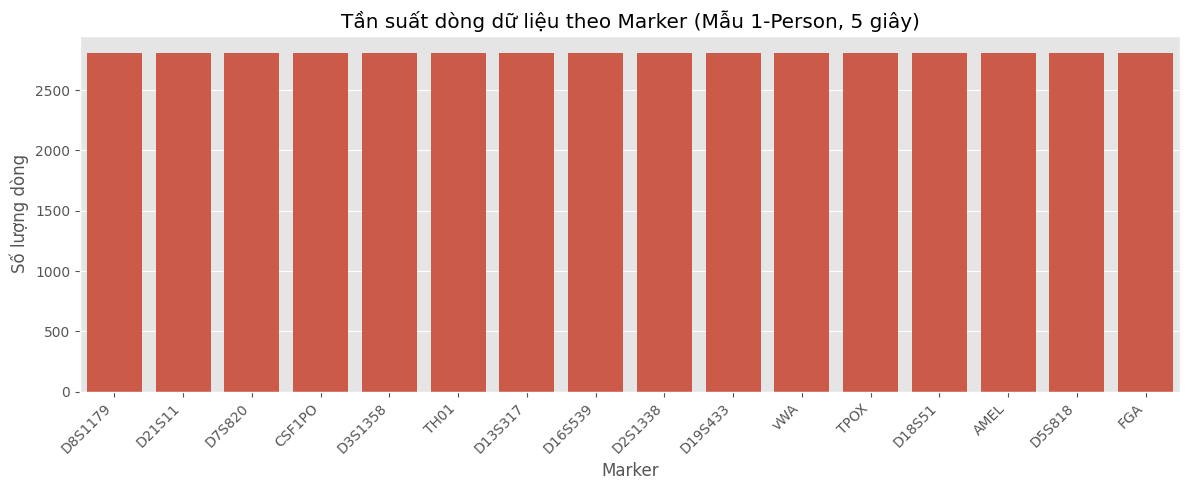

Số lượng dòng theo Dye (Kênh màu học):
Dye
G    14050
B    11240
Y    11240
R     8430
Name: count, dtype: int64


In [6]:
plt.figure(figsize=(12, 5))
sns.countplot(data=df_sample, x='Marker', order=df_sample['Marker'].value_counts().index)
plt.xticks(rotation=45, ha='right')
plt.title('Tần suất dòng dữ liệu theo Marker (Mẫu 1-Person, 5 giây)')
plt.ylabel('Số lượng dòng')
plt.tight_layout()
plt.show()

print("Số lượng dòng theo Dye (Kênh màu học):")
print(df_sample['Dye'].value_counts())

## 4. Phân tích Dữ liệu Điển hình: OL và X/Y (Nhiễm sắc thể Giới tính)
Dữ liệu DNA thô thường chứa các tín hiệu `OL` (Off-Ladder: allele không khớp kích thước chuẩn) và `X`, `Y` tại locus AMEL.
Dưới đây là đoạn code đếm tổng quan các giá trị này.

In [7]:
def detect_anomalies(df):
    allele_cols = [c for c in df.columns if c.startswith('Allele')]
    
    # Đếm OL
    ol_count = (df[allele_cols] == 'OL').sum().sum()
    
    # Đếm X, Y
    x_count = (df[allele_cols] == 'X').sum().sum()
    y_count = (df[allele_cols] == 'Y').sum().sum()
    
    # Tín hiệu AMEL
    amel_rows = df[df['Marker'] == 'AMEL'].shape[0]
    
    print(f"Tổng số giá trị 'OL': {ol_count}")
    print(f"Tổng số giá trị 'X': {x_count}")
    print(f"Tổng số giá trị 'Y': {y_count}")
    print(f"Tổng số dòng thuộc Marker AMEL: {amel_rows}")
    
    return df[df['Marker'] == 'AMEL'].head()

detect_anomalies(df_sample)

Tổng số giá trị 'OL': 180412
Tổng số giá trị 'X': 2546
Tổng số giá trị 'Y': 2277
Tổng số dòng thuộc Marker AMEL: 2810


,Sample File,Marker,Dye,Allele 1,Size 1,Height 1,Allele 2,Size 2,Height 2,Allele 3,Size 3,Height 3,Allele 4,Size 4,Height 4,Allele 5,Size 5,Height 5,Allele 6,Size 6,Height 6,Allele 7,Size 7,Height 7,Allele 8,Size 8,Height 8,Allele 9,Size 9,Height 9,Allele 10,Size 10,Height 10,Allele 11,Size 11,Height 11,Allele 12,Size 12,Height 12,Allele 13,Size 13,Height 13,Allele 14,Size 14,Height 14,Allele 15,Size 15,Height 15,Allele 16,Size 16,Height 16,Allele 17,Size 17,Height 17,Allele 18,Size 18,Height 18,Allele 19,Size 19,Height 19,Allele 20,Size 20,Height 20,Allele 21,Size 21,Height 21,Allele 22,Size 22,Height 22,Allele 23,Size 23,Height 23,Allele 24,Size 24,Height 24,Allele 25,Size 25,Height 25,Allele 26,Size 26,Height 26,Allele 27,Size 27,Height 27,Allele 28,Size 28,Height 28,Allele 29,Size 29,Height 29,Allele 30,Size 30,Height 30,Allele 31,Size 31,Height 31,Allele 32,Size 32,Height 32,Allele 33,Size 33,Height 33,Allele 34,Size 34,Height 34,Allele 35,Size 35,Height 35,Allele 36,Size 36,Height 36,Allele 37,Size 37,Height 37,Allele 38,Size 38,Height 38,Allele 39,Size 39,Height 39,Allele 40,Size 40,Height 40,Allele 41,Size 41,Height 41,Allele 42,Size 42,Height 42,Allele 43,Size 43,Height 43,Allele 44,Size 44,Height 44,Allele 45,Size 45,Height 45,Allele 46,Size 46,Height 46,Allele 47,Size 47,Height 47,Allele 48,Size 48,Height 48,Allele 49,Size 49,Height 49,Allele 50,Size 50,Height 50,Allele 51,Size 51,Height 51,Allele 52,Size 52,Height 52,Allele 53,Size 53,Height 53,Allele 54,Size 54,Height 54,Allele 55,Size 55,Height 55,Allele 56,Size 56,Height 56,Allele 57,Size 57,Height 57,Allele 58,Size 58,Height 58,Allele 59,Size 59,Height 59,Allele 60,Size 60,Height 60,Allele 61,Size 61,Height 61,Allele 62,Size 62,Height 62,Allele 63,Size 63,Height 63,Allele 64,Size 64,Height 64,Allele 65,Size 65,Height 65,Allele 66,Size 66,Height 66,Allele 67,Size 67,Height 67,Allele 68,Size 68,Height 68,Allele 69,Size 69,Height 69,Allele 70,Size 70,Height 70,Allele 71,Size 71,Height 71,Allele 72,Size 72,Height 72,Allele 73,Size 73,Height 73,Allele 74,Size 74,Height 74,Allele 75,Size 75,Height 75,Allele 76,Size 76,Height 76,Allele 77,Size 77,Height 77,Allele 78,Size 78,Height 78,Allele 79,Size 79,Height 79,Allele 80,Size 80,Height 80,Allele 81,Size 81,Height 81,Allele 82,Size 82,Height 82,Allele 83,Size 83,Height 83,Allele 84,Size 84,Height 84,Allele 85,Size 85,Height 85,Allele 86,Size 86,Height 86,Allele 87,Size 87,Height 87,Allele 88,Size 88,Height 88,Allele 89,Size 89,Height 89,Allele 90,Size 90,Height 90,Allele 91,Size 91,Height 91,Allele 92,Size 92,Height 92,Allele 93,Size 93,Height 93,Allele 94,Size 94,Height 94,Allele 95,Size 95,Height 95,Allele 96,Size 96,Height 96,Allele 97,Size 97,Height 97,Allele 98,Size 98,Height 98,Allele 99,Size 99,Height 99,Allele 100,Size 100,Height 100
13,A02_RD14-0003-23d3a-0.2IP-Q1.2_001.5sec.fsa,AMEL,R,X,104.96,196.0,Y,110.90,381.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

## 5. Phân tích Phân phối Tín hiệu Đỉnh (Peak Heights / RFU)
Relative Fluorescence Units (RFU) biểu thị cấu hình tín hiệu của các Allele. Việc hiểu phân phối chiều cao giúp quyết định Threshold để lọc nhiễu (stutters).

Thống kê mô tả Height (RFU):
count    131700.000000
mean         50.291207
std         162.995553
min           1.000000
25%           4.000000
50%           7.000000
75%          14.000000
max        3691.000000
dtype: float64


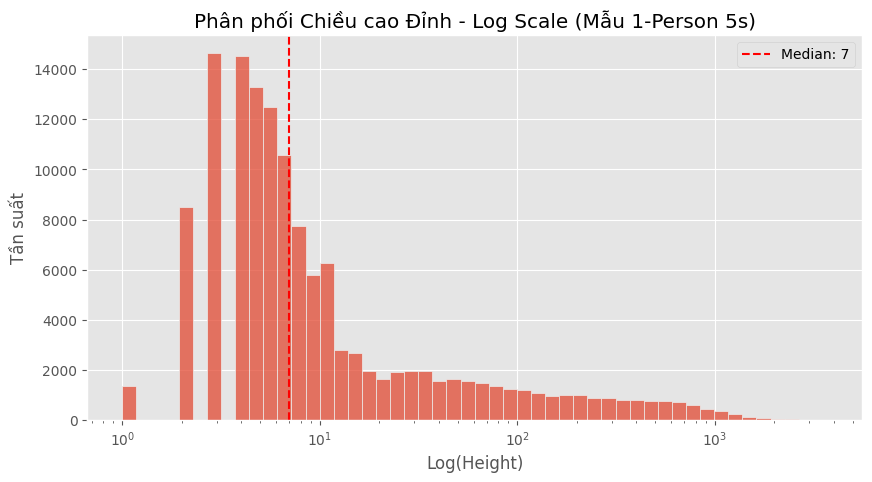

In [8]:
# Trích xuất tất cả các giá trị Height hợp lệ trong 3 cột đầu
height_cols = ['Height 1', 'Height 2', 'Height 3']
heights = pd.to_numeric(df_sample[height_cols].values.flatten(), errors='coerce')
heights = heights[~np.isnan(heights)]  # Loại bỏ NaN

print("Thống kê mô tả Height (RFU):")
print(pd.Series(heights).describe())

# Vẽ histogram log-scale
plt.figure(figsize=(10, 5))
sns.histplot(heights, bins=50, log_scale=(True, False))
plt.title('Phân phối Chiều cao Đỉnh - Log Scale (Mẫu 1-Person 5s)')
plt.xlabel('Log(Height)')
plt.ylabel('Tần suất')
plt.axvline(np.median(heights), color='red', linestyle='--', label=f'Median: {np.median(heights):.0f}')
plt.legend()
plt.show()

## 6. Tổng kết và Đề xuất Tiền xử lý (Preprocessing Recommendations)

Dựa trên các đánh giá trên, khi xử lý dữ liệu cho mô hình Pipeline (ví dụ: mô hình TAWSEEM CNN / XGBoost), ta cần thực hiện các quy trình:
1. **Xử lý AMEL (Giới tính):** Các cột Allele chứa chuỗi `'X'` và `'Y'`. Cần loại bỏ toàn bộ các dòng `Marker == 'AMEL'` vì giới tính không đóng góp cho bài toán xác định Số người (NOC).
2. **Xử lý OL (Off-Ladder):** Đánh dấu các chuỗi `'OL'` bằng một feature nhị phân riêng biệt (ví dụ `OL_ind = 1`) và thay thế giá trị chuỗi thành một hằng số thực (như `0.0` hoặc `-1.0`) để giữ tính liên tục của tensor numeric.
3. **Lọc nhiễu:** RFU (Height) có phương sai rất lớn. Có thể cần chuẩn hóa (Normalization) hoặc lọc bỏ các tín hiệu nhỏ (dưới chuẩn Threshold của PTN).
4. **Missing Values:** Dữ liệu có rất nhiều cột (lên tới Allele 100), đa số sẽ là `NaN`. Có thể cần giới hạn lại số lượng Allele tối đa (ví dụ cắt ở Allele 10) để bảo toàn kích thước feature matrix hợp lý.
